# Investigating parameters effects on Sensitivity of the OGGM Mass Balance and Runoff Models

In this notebook we will explore the sensitivity of OGGM's mass-balance and runoff models using SAFE. We will focus on the three parameters: melt factor, precipitation factor and temperature bias.

We will start by applying one-at-a-time sensitivity analysis to get a feel for how much each parameter affects the model and output. We will then consider the uncertainty of these sensitivities and work to quantify them.

## Sensitivity Analysis with the OGGM Mass Balance Model

We will apply sensitivity analysis in the following order to investigate our model behaviour:

1. **One-at-a-time**: We will apply one-at-a-time analysis , in which we change one parameter at a time and see how the mass balance changes in accordance. To show this, we will plot an interactive mass balance time series with toggles, where the parameter values can be changed within their default boundaries.
2. **Global sensitivity analysis**: Here we will use AAT sampling to randomly sample a combination of the 3 parameters and investigate the sensitivity in the following ways
    a. Qualitative - scatter plots
    b. Quantitative - RSA and bootstrapping

This will be applied first to the mass balance model in the OGGM, and then to the runoff model in the OGGM.

First we install the packages we require from both OGGM and SAFE.

In [2]:
import matplotlib.pyplot as plt
import os
import numpy as np
import scipy.stats as st
import pandas as pd

from oggm import cfg, workflow, utils
from oggm.core import flowline, sensitivity
from oggm import tasks
from oggm.core.massbalance import MultipleFlowlineMassBalance

# Install python package for interactive visualisation and import required functions:
%pip install -q ipywidgets
from ipywidgets import interact

# Install SAFE package and import required functions
%pip install SAFEpython

import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
from safepython.sampling import AAT_sampling # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping
import safepython.plot_functions as pf

from oggm.core.sensitivity import hydro_output_metric_calculator, run_with_runoff_for_sa, runoff_execution, mean_diff, parameter_bounding, spinup_area_volume

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv). We will load in the glacier directories and ensure our configuration is as required for our runs.

In [14]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = "/mnt/c/Users/yg25019/Documents/sensitivity_output"
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

# WH01
rgi_id = 'RGI60-14.03000'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_wh01 = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

# Get the Hugonnet mass balance and set up dataframe

geo_df = utils.get_geodetic_mb_dataframe()
geo_df.loc[gdir_wh01.rgi_id]

# Hydrological model workflow steps before running with hydro
cfg.PARAMS['evolution_model'] = 'FluxBased'
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['error_when_glacier_reaches_boundaries'] = False

cfg.PARAMS['use_multiprocessing'] = True  # To speed up sensitivity analysis runs
cfg.PARAMS['mp_processes'] = os.cpu_count()  # Use all available cores

2026-03-04 11:43:49: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-03-04 11:43:49: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-03-04 11:43:49: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-03-04 11:43:49: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-03-04 11:43:49: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-03-04 11:43:49: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.
2026-03-04 11:43:49: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-03-04 11:43:49: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2026-03-04 11:43:49: oggm.cfg: PARAMS['evolution_model'] changed from `SemiImplicit` to `FluxBased`.
2026-03-04 11:43:49: oggm.cfg: PARAMS['error_when_glacier_reaches_boundaries'] changed from `True` to `False`.
2026-03-04 11:43:49: oggm.cfg: Multiprocessing switched 

In [23]:
print("RGI Date", gdir_wh01.rgi_date)
print("RGI Date", gdir_wh01.rgi_area_km2)

RGI Date 1999
RGI Date 0.059


# Step 1 - The OGGM Runner, to produce runoff simulations

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

This runner will produce a timeseries for the runoff.

The method will use run_with_hydro to create the hydrological data required to calculate the runoff in the OGGM.

The below method calculates the output metrics we will be using to understand the output of our hydrological simulations and our runoff timeseries. We currently do not have any observed data and so we are unsure of the values to expect, but we can still look into the mean and standard deviation, and use these in our sensitivity analysis.

Using the mean and standard deviation can give us a good picture of the data we have generated.

In [10]:
gdir_hef.rgi_area_km2 # plus or minus 10 percent here
gdir_hef.rgi_date # At this date specifically

2003

In [11]:
# And match the Hugonnet
geo_df = utils.get_geodetic_mb_dataframe()
geo_df.loc[gdir_hef.rgi_id]

,period,area,dmdtda,err_dmdtda,reg,is_cor
rgiid,,,,,,
RGI60-11.00897,2000-01-01_2010-01-01,8036000.0,-1.0425,0.2610,11,False
RGI60-11.00897,2000-01-01_2020-01-01,8036000.0,-1.1003,0.1718,11,False
RGI60-11.00897,2010-01-01_2020-01-01,8036000.0,-1.1580,0.2427,11,False


## Taking samples and producing the runoff in the OGGM

In [37]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

# gdir_hef.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this? 
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 1.0, -3]) # Minimum values for each parameter
x_max = np.array([7.0, 5.0, 3]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 1000 # Number of samples

    Note: Will only need to run this once! Once it has run, the CSVs with the outputs will be saved

In [ ]:
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

YY = runoff_execution(fun_test = run_with_runoff_for_sa, 
                 X = X, # All samples
                 gdir = gdir_hef, # Hinteresfirner Glacier directory
                 years =range(1979, 2020), # years
                 init_model_yr = 1901, # Simulation start year - needs to be early enough to allow for spinup before the period we are interested in
                 ys =1901, # Start of the simulation
                 min_ys = 1901, # Minimum start year
                 ref_area_yr = 2004, # Reference area year - needs to be a year for which we have observed area data for the glacier, so we can use this to constrain the modelled glacier area during the spinup period
                 spinup_period = 21, # Spinup period in years (we are cutting this off, once the glacier has reached an equilibrium state, but this can be changed to a different period if desired)
                 csv_filepath = 'hinteresfirner_runoff_output.csv',
                 params_csv_filepath='hinteresfirner_params.csv',
                 run_task = tasks.run_from_climate_data,
                 mb_model_method = MultipleFlowlineMassBalance)

2026-03-04 11:21:55: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2026-03-04 11:21:55: oggm.workflow: Execute entity tasks [run_with_runoff_for_sa] on 1000 glaciers


2026-03-04 11:21:57: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-04 11:21:57: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-04 11:21:57: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-04 11:21:58: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-04 11:21:59: oggm.core.flowline: You are attempting to run_with_clim

## Parameter Space Study

The OGGM uses extremely large default parameter ranges, that for specific glaciers are completely unrealistic. Here we perform some studies on the parameter space to understand which ranges are feasible, if there are any trends we can take into account for our data and if we can optimise our sampling approach. The outline of the methodology is as follows:
1. Sampling the parameter space uniformly with large ranges and an initial, qualitative investigation if any patterns emerge.
2. Comparison with the observed data we have avaliable: area and mass balance, we can investigate the combinations of parameters that cause a large deivation from the observed values.
    a. Here we can start with an AAT investigation, as our inputs are not independent.
3. From this initial study, it may become apparent that our ranges can be reduced. If this is obvious, we can reduce the ranges and resample with the updated parameter ranges.
4. Running the simulations again, we can now investigate the sampling strategy and distributions. From here some more complex techniques can be investigated and we can compare which behaves the best.

## Experiment #1: A uniform sampling of the OGGM's default sample space.

We start off simply with the OGGM's default sample space, which has large ranges for the melt_f, prcp_fac and temp_bias. We have used a uniform distribution to sample these in a LHS technique using AAT.

Firstly, lets plot the mass balance alongside the observed mass balance value to understand how much our outputs are currently varying from the parameters we are sampling and if there is a large difference between our simulated and observed values.

In [19]:
# compile CSVs to plot timeseries and plot to view the mass balance time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
mass_balance_samples = []
years = []
runoff_samples = []
area_samples = []
volume_samples = []
params = []

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_hinteresfirner_runoff_output.csv')
    mass_balance_samples.append(df['mass_balance'].values)
    years.append(df['years'].values)
    runoff_samples.append(df['runoff_Mt'].values)
    area_samples.append(df['area_km2'].values)
    volume_samples.append(df['volume_km3'].values)

    mb_param_df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_hinteresfirner_params.csv') 
    params.append(mb_param_df['params'])

try:
    X
except NameError:
    X = np.vstack([p.values for p in params])

try:
    YY
except NameError:
    YY = hydro_output_metric_calculator(runoff_samples)

## Plotting our output timeseries

## Mass Balance

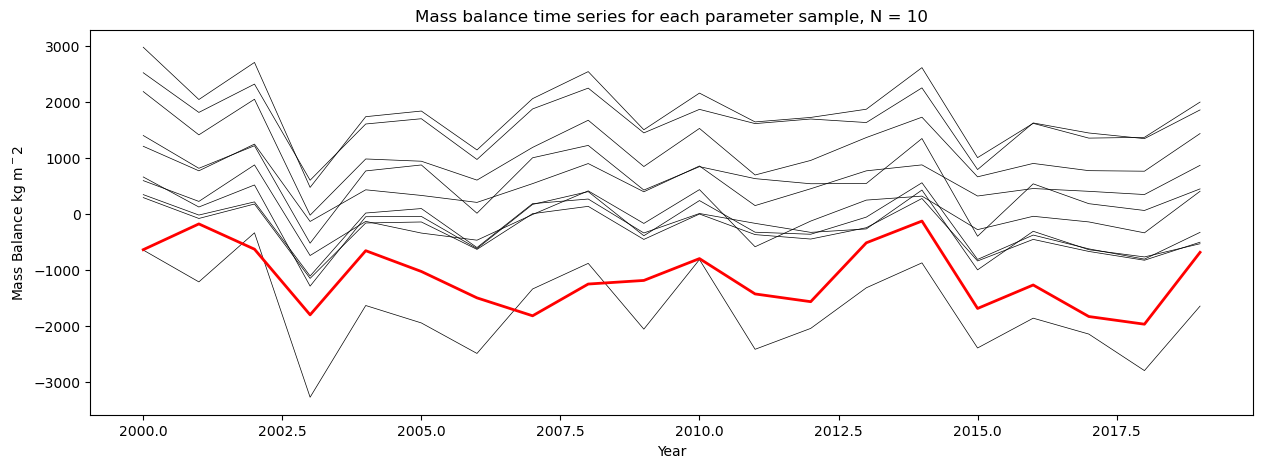

In [20]:
# compile csvs to plot timeseries and plot to view the mass balance time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
plt.figure(figsize=(15,5))

for i in range(N):
    plt.plot(years[i], mass_balance_samples[i], label='sim', color='k', linewidth=0.5)

plt.title('Mass balance time series for each parameter sample, N = %d' % N)
plt.xlabel('Year'), plt.ylabel('Mass Balance kg m$^-2$')
plt.plot(range(2000,2020), mbdf['in_situ_mb'].loc[2000:2019], label='obs', color='r', linewidth=2)

## Area

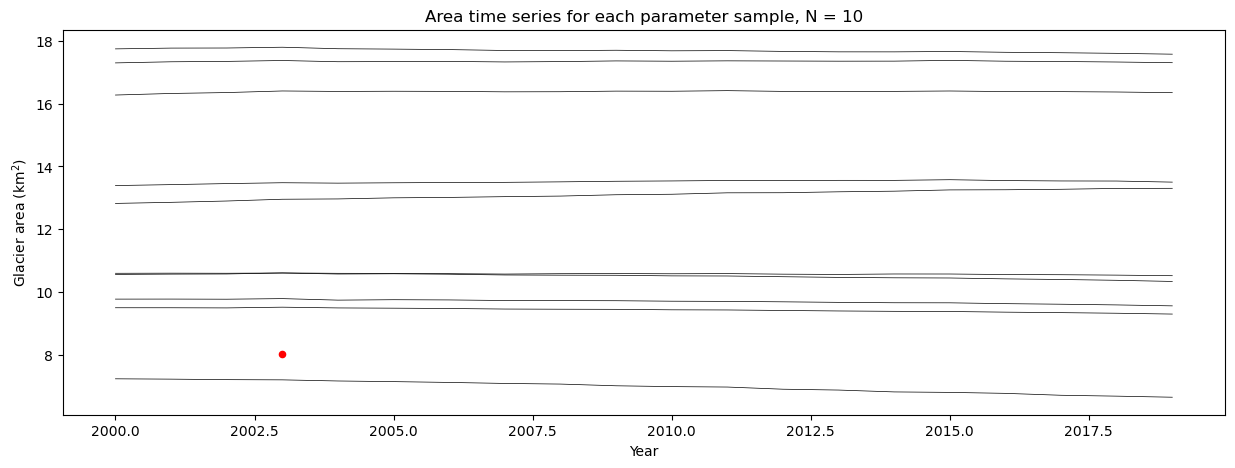

In [22]:
plt.figure(figsize=(15,5))

# Check the area from the observed, why is it so low compared to the simulation?

for i in range(N):
    area_km2 = area_samples[i]
    plt.plot(years[i], area_km2, label='sim', color='k', linewidth=0.5)
    
plt.scatter(gdir_hef.rgi_date, gdir_hef.rgi_area_km2, color='r', s=20, zorder=999)
plt.title('Area time series for each parameter sample, N = %d' % N)
plt.ylabel('Glacier area (km$^2$)')
plt.xlabel('Year')
plt.show()

## Volume

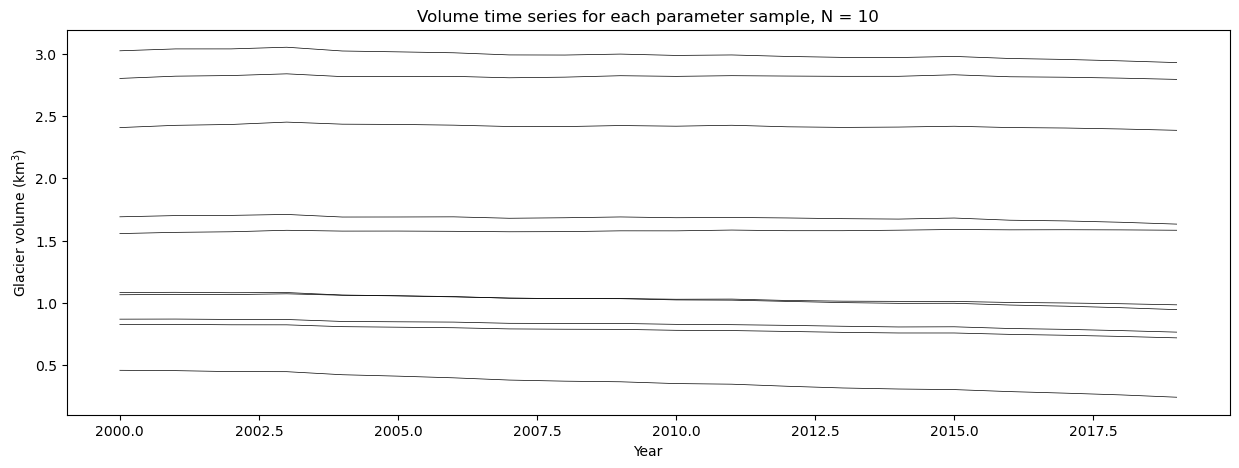

In [23]:
# Update this to continue for the entire period
plt.figure(figsize=(15,5))

for i in range(N):
    volume_km3 = volume_samples[i]
    plt.plot(years[i], volume_km3, label='sim', color='k', linewidth=0.5)
    plt.title('Volume time series for each parameter sample, N = %d' % N)

plt.ylabel('Glacier volume (km$^3$)')
plt.xlabel('Year')

plt.show()

## Runoff

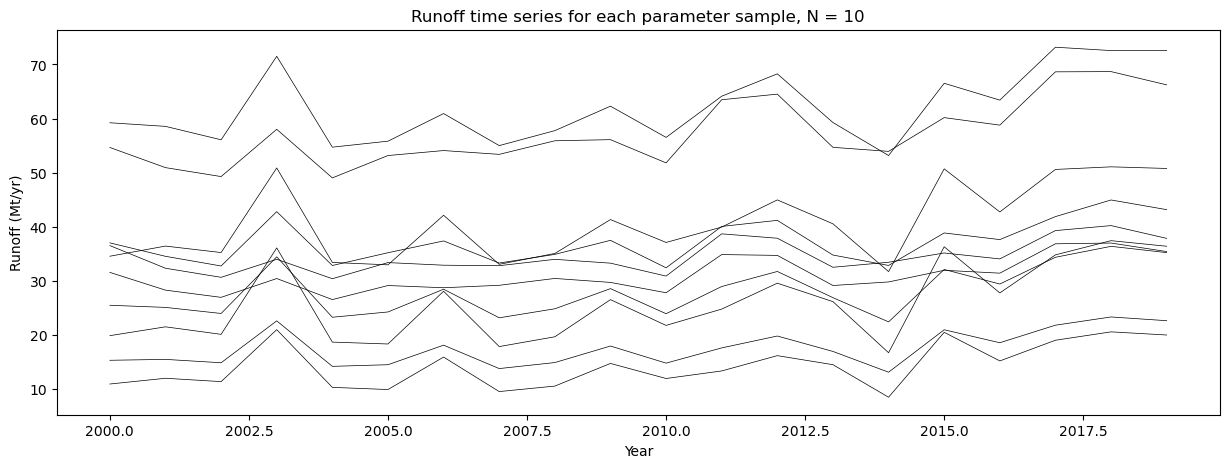

In [24]:
# compile csvs to plot timeseries and plot to view the runoff time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
plt.figure(figsize=(15,5))

for i in range(N):
    plt.plot(years[i], runoff_samples[i], label='sim', color='k', linewidth=0.5)
    plt.title('Runoff time series for each parameter sample, N = %d' % N)

plt.ylabel('Runoff (Mt/yr)')
plt.xlabel('Year')

plt.show()

## Inputs

Investigating the distribution of the input parameters compared to the output parameters. In our study, initially we are using a uniform sampling distribution. As we would expect, the distributions here are of uniform distribution, as we had specified. Firstly, if we restart our notebook we can use our variables! We have stored everything we need in a CSV, so if required we can recover these without running a lengthy set of simulations again.

In [ ]:
try:
    X
except NameError:
    X = np.vstack([p.values for p in params])

try:
    YY
except NameError:
    YY = hydro_output_metric_calculator(runoff_samples)

Investigating the distribution of our inputs, checking ther are as we would expect:

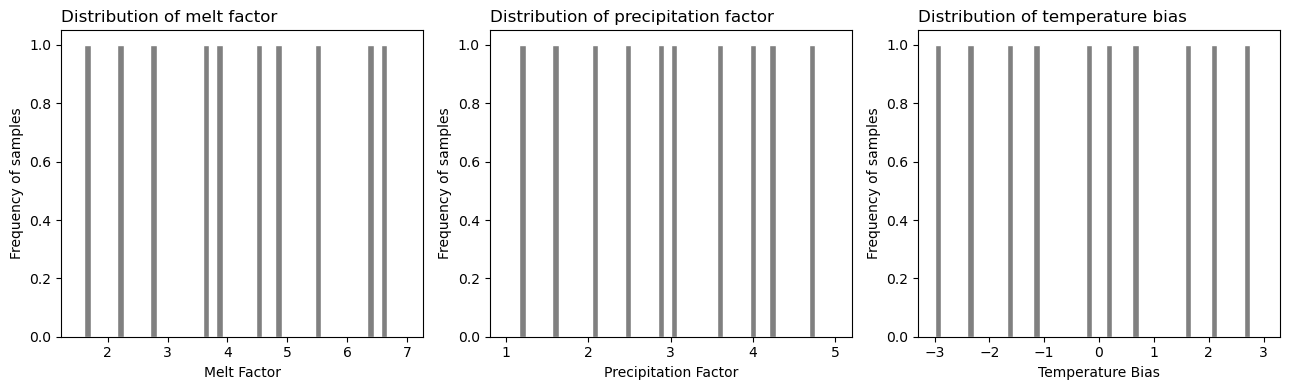

In [25]:
import numpy as np
import matplotlib.pyplot as plt

melt_low, melt_high = x_min[0], x_max[0]
precip_low, precip_high = x_min[1], x_max[1]
tbias_low, tbias_high = x_min[2], x_max[2]
nbins = 50

bins_melt   = np.linspace(melt_low,   melt_high,   nbins+1)
bins_precip = np.linspace(precip_low, precip_high, nbins+1)
bins_tbias  = np.linspace(tbias_low,  tbias_high,  nbins+1)

plt.figure(figsize=(13, 4))

plt.subplot(1,3,1)
plt.title('Distribution of melt factor', loc='left')
plt.hist(X[:,0], bins=bins_melt, range=(melt_low, melt_high),
         color='grey', edgecolor='white')
plt.ylabel('Frequency of samples'); plt.xlabel('Melt Factor')

plt.subplot(1,3,2)
plt.title('Distribution of precipitation factor', loc='left')
plt.hist(X[:,1], bins=bins_precip, range=(precip_low, precip_high),
         color='grey', edgecolor='white')
plt.ylabel('Frequency of samples'); plt.xlabel('Precipitation Factor')

plt.subplot(1,3,3)
plt.title('Distribution of temperature bias', loc='left')
plt.hist(X[:,2], bins=bins_tbias, range=(tbias_low, tbias_high),
         color='grey', edgecolor='white')
plt.ylabel('Frequency of samples'); plt.xlabel('Temperature Bias')

plt.tight_layout()
plt.show()

These inputs are as we would expect, we required a uniform sampling and this is what we can seee in the three graphs above.

In [26]:
from oggm.utils import rmsd

mass_balances = []
mean_mass_balances = []
std_mass_balances = []
rmsds = []

for i in range(N):
    mean_mass_balances.append(mass_balance_samples[i].mean())
    std_mass_balances.append(mass_balance_samples[i].std())
    rmsds.append(rmsd(mass_balance_samples[i], mbdf['in_situ_mb'].loc[2000:2019]))


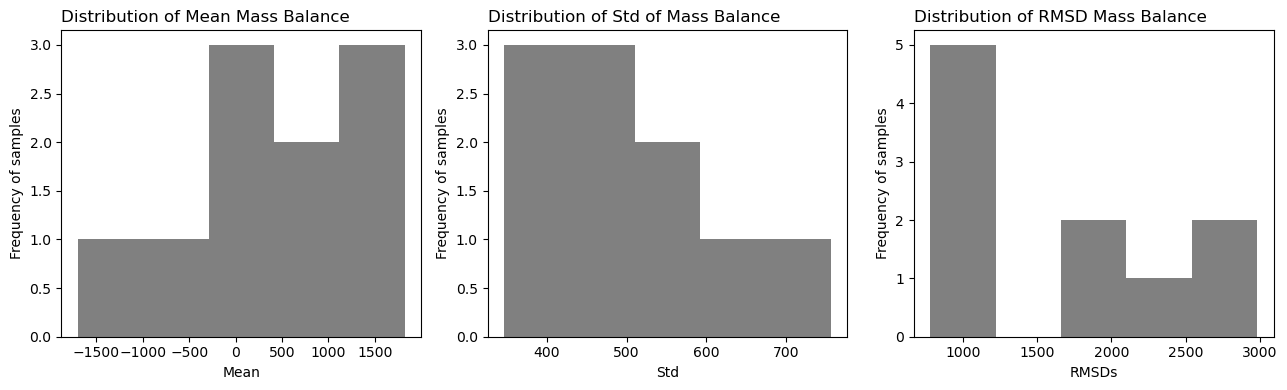

In [27]:
plt.figure(figsize=[13,4])

min_means, max_means = np.min(mean_mass_balances), np.max(mean_mass_balances)
min_stds, max_stds = np.min(std_mass_balances), np.max(std_mass_balances)
min_rmsds, max_rmsds = np.min(rmsds), np.max(rmsds)

nbins = 50

bins_means = np.linspace(min_means, max_means, nbins+1)
bins_stds = np.linspace(min_stds, max_stds, nbins+1)
bins_rmsds  = np.linspace(min_rmsds, max_rmsds,  nbins+1)

plt.subplot(1,3,1), plt.title('Distribution of Mean Mass Balance', loc='left'), plt.hist(mean_mass_balances, bins='auto', 
                                                                                         range=(min_means, max_means), color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel('Mean')

plt.subplot(1,3,2), plt.title('Distribution of Std of Mass Balance', loc='left'), plt.hist(std_mass_balances, bins='auto', 
                                                                                         range=(min_stds, max_stds), color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel('Std')

plt.subplot(1,3,3), plt.title('Distribution of RMSD Mass Balance', loc='left'), plt.hist(rmsds, bins='auto', 
                                                                                         range=(min_rmsds, max_rmsds), color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel('RMSDs')

plt.tight_layout()

We can see that the mean mass balance and the standard deviation of the mass balance are both normally distributed. And we can see that the RMSD is heavily skewed towards lower values.

This indicates that there are likely other influences on the model that would drive this output behaviour, and the nature of the inputs do not wholly control the nature of the outputs.

Now, lets plot our two output metrics together the mean and standard deviation of the runoff.

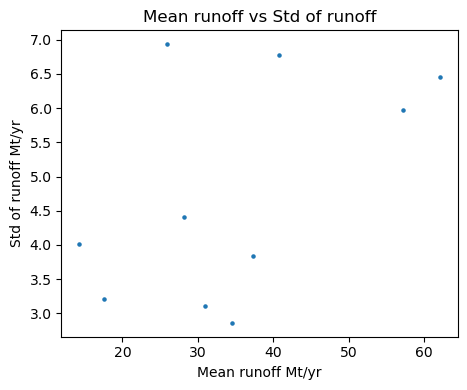

In [28]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY[:,0], YY[:,1], s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff Mt/yr'), plt.ylabel('Std of runoff Mt/yr'),

plt.tight_layout()
plt.show()

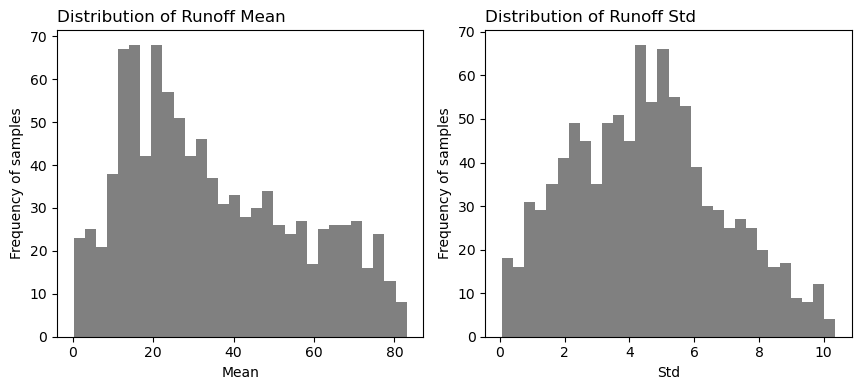

In [ ]:
plt.figure(figsize=[13,4])


min_mean_ro, max_mean_ro = np.min(YY[:,0]), np.max(YY[:,0])
min_std_ro, max_std_ro = np.min(YY[:,1]), np.max(YY[:,1])

nbins = 30

bins_mean_ro = np.linspace(min_mean_ro, max_mean_ro, nbins+1)
bins_std_ro = np.linspace(min_std_ro, max_std_ro, nbins+1)

plt.subplot(1,3,1), plt.title('Distribution of Runoff Mean', loc='left'), 
plt.hist(YY[:,0], bins=bins_mean_ro, color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel('Mean')

plt.subplot(1,3,2), plt.title('Distribution of Runoff Std', loc='left'), 
plt.hist(YY[:,1], bins=bins_std_ro, color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel('Std')
plt.tight_layout()

## Qualitative sensitivity

In [ ]:
Y_Labels = ['Mean Runoff', 'Std of Runoff']

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

From this we can already see qualitatively that we would expect, for the runoff mean that the precipitation would be the most significant in sensitivity. We can see for the std of the runoff that the temperature bias would be likely the most significant for sensitivity. This is confirmed by our PAWN sensitivity analysis that we performed above.

We can investigate how the sensitivity looks right now, where we know our parameter ranges are not correct and are infact too large. this to before to understand how reducing our parameter ranges has affected the sensitivity. This can help us understand if any parameters are currently dominating and we will use this to compare later.

## Quantitative Sensitivity

## PAWN Sensitivity

In [ ]:
# Define interactive visualisation function to calculate and visualise sensitivity indices
# for the chosen output metric and different choices of the PAWN tuning parameters (n,Nboot,aggr)

def runoff_pawn_function(metric='Mean Runoff', n = 5, aggr = 'median', Nboot = 500):
    # Extract output metric:
    if metric == 'Mean Runoff':
        i = 0
    elif metric == 'Std of Runoff':
        i = 1   
    Y = YY[:, i]; 

    X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
    
    # Apply PAWN
    # Tuning parameters:
    # n = number of conditioning intervals
    # aggr = statistic to aggregate KS values
    # Nboot = number of bootstrapping resamples used to derive confidence bounds of sensitivity indices   

    # Compute sensitivity indices for Nboot bootstrap resamples
    KS_median, KS_mean, KS_max = PAWN.pawn_indices(X, Y, n, Nboot=Nboot)
    # KS_median and KS_mean and KS_max have shape (Nboot, M)
        
    # Compute mean and confidence intervals of the sensitivity indices across the bootstrap resamples:
    KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median) # shape (M,)
    KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean) # shape (M,)
    KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max) # shape (M,)

    # Plot sensitivity indices:
    plt.figure()
    plt.title("Output Metric for the Runoff = %s" % metric)
    if aggr == 'median':
        pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub, X_Labels=X_labels, Y_Label='sensitivity (median KS)')
    if aggr == 'mean':
        pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub, X_Labels=X_labels, Y_Label='sensitivity (mean KS)')
    if aggr == 'max':
        pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub, X_Labels=X_labels, Y_Label='sensitivity (max KS)')
    plt.show()

interact(runoff_pawn_function, metric = ['Mean Runoff','Std of Runoff'], n = (2, 20, 1), aggr = ['median', 'mean','max'], Nboot = (0, 500, 10));


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

We can see that for sensitivity, with the parameter bounds that we have chosen, that for the mean of the runoff, `prcp_fac` is significantly the most impactful parameter, and also appears to have (perhaps) the largest uncertainty.

And for the standard deviation of the runoff, that the `temp_bias` parameter appears to be both the most significant and the most uncertain, with `prcp_fac` following closely behind.

## Investigation to reduce range

Sensitivity analysis is highly reliant on the parameter space chosen in the inputs we are investigating. If they are too large or too small this could seriously throw off our sensitivity results. We know that our parameter ranges are a bit too large for our first try, but we don't necessarily know what the appropriate, more "realistic" ranges of parameters could be here. We do however have the mean annual mass balance value. We can try and reduce the mean bias as much as possible to gather a more realistic range of parameter values to make our sensitvity analysis more appropriate.

Let's investigate the mean bias to investigate the overall fit of our simulations to the observed data. From this analysis, we can derive a set of parameters that are within a specific tolerance to attempt to tune our parameter ranges a bit more closely.

Firstly, let's investigate that we can actually apply linear regression here to be able to constrain our values.

In [ ]:
# compile csvs to plot timeseries and plot to view the mass balance time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
success_index_mean = []

# Colormap and normalization
cmap = plt.cm.coolwarm

# Using the RMSD as a metric to evaluate the success of each simulation, we can colour the lines based on the RMSD value, with a colourbar to show the range of RMSD values. 
# This will allow us to visually identify which simulations are performing better or worse in terms of matching the observed mass balance time series.
for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    success_index_mean.append(mean_diff(df['mass_balance'].values, mbdf['in_situ_mb'].loc[df['years'].iloc[0]:df['years'].iloc[-1]].values))

vmin_mean = min(success_index_mean)
vmax_mean = max(success_index_mean)
norm_mean = plt.Normalize(vmin=vmin_mean, vmax=vmax_mean)

Now colour mapping the mean bias to the mass balance timeseries.

<Figure size 1500x500 with 0 Axes>

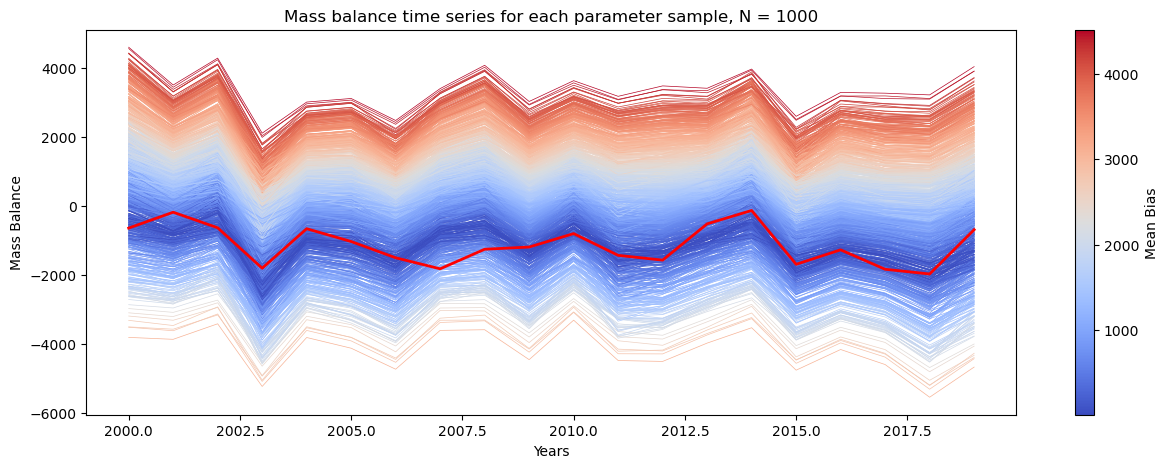

In [ ]:
plt.figure(figsize=(15,5))
fig, ax = plt.subplots(figsize=(15, 5))

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    color = cmap(norm_mean(success_index_mean[i]))
    plt.plot(df['years'], df['mass_balance'], label='sim', color=color, linewidth=0.5)
    plt.title('Mass balance time series for each parameter sample, N = %d' % N)

# Add colorbar linked to the same colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_mean)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Mean Bias')

plt.xlabel('Years')
plt.ylabel('Mass Balance')
plt.plot(range(2000,2020), mbdf['in_situ_mb'].loc[2000:2019], label='obs', color='r', linewidth=2)

Let's see if this affects the runoff time series in the same way!

<Figure size 1500x500 with 0 Axes>

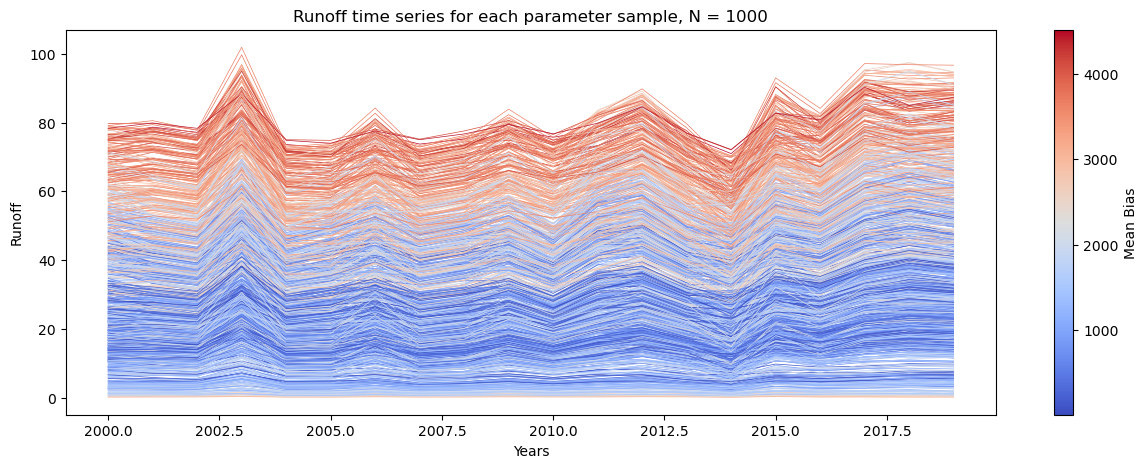

In [ ]:
plt.figure(figsize=(15,5))
fig, ax = plt.subplots(figsize=(15, 5))

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    color = cmap(norm_mean(success_index_mean[i]))
    plt.plot(df['years'], df['runoff'], label='sim', color=color, linewidth=0.5)
    plt.title('Runoff time series for each parameter sample, N = %d' % N)

# Add colorbar linked to the same colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_mean)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Mean Bias')

plt.ylabel('Runoff')
plt.xlabel('Years')
plt.show()

This does affect the runoff similarly! The relationship is perhaps not quite as clean as it is with the mass balance timeseries, but there is still a very clear gradient of the mean bias.

We can see there are some very large mean bias values here. Now let's investigate these by colour coding our parameters. Due to the very large range of temp_bias it's relationship with the other parameters, lets investigate the behaviour of the samples taken of temp_bias and see if we can reduce the range at all.

Let's perhaps choose the values with the Mean Bias below a specific threshold and see if this reduces our parameter ranges.

Now we investigate these points against the Mean MB Bias to see if the values towards the end of the scale do infact cause the Mean MB Bias to be excessively large.

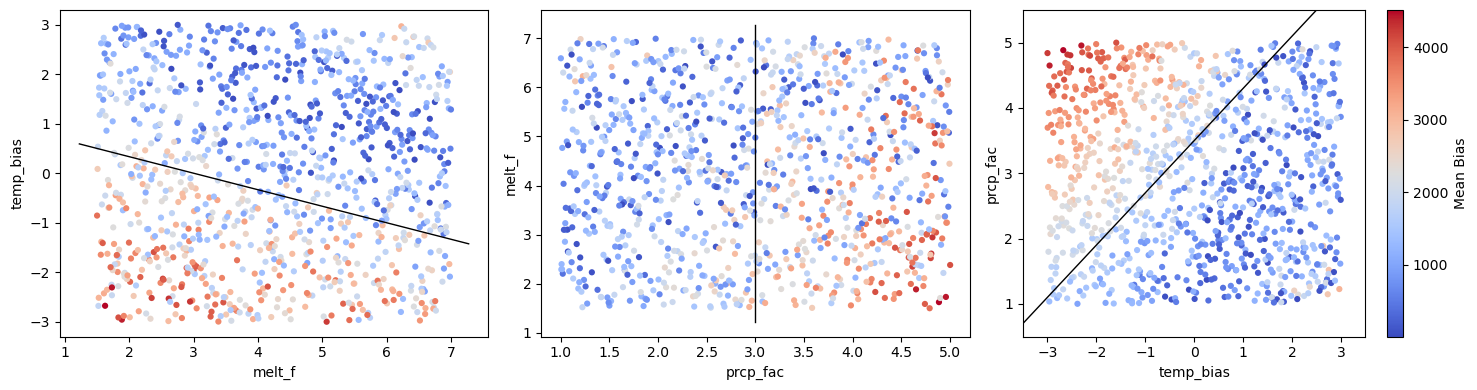

In [ ]:
M = X.shape[1]

import numpy as np
import matplotlib.pyplot as plt

success_index = np.asarray(success_index_mean)
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=success_index.min(), vmax=success_index.max())

j = (i - 1) % X.shape[1]  # previous column (wraps around)
plt.figure(figsize=[15,4])

for i in range(M):
    plt.subplot(1,3,i+1)
    sc = plt.scatter(
        X[:, i], X[:, i-1],
        c=success_index, cmap=cmap, norm=norm, s=20, edgecolors="none"
        )
    if i == 0:   
        
        xmin, xmax = plt.xlim()
        x = np.array([xmin, xmax])
        y = -(1/3)*x + 1

        plt.plot(x, y, color='black', linewidth=1)
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])
    if i == 1:
        ymin, ymax = plt.ylim()
        y = np.array([ymin, ymax])
        x = 3 * np.ones_like(y)

        plt.plot(x, y, color='black', linewidth=1)
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])
    if i == 2:
        plt.xlim((-3.5, 3.5))
        plt.ylim((0.5, 5.5))
        xmin, xmax = plt.xlim()
        x = np.array([xmin, xmax])
        y = 0.8*x + 3.5

        plt.plot(x, y, color='black', linewidth=1)
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])

cbar = plt.colorbar(sc)
cbar.set_label("Mean Bias")
ax = plt.gca()

plt.tight_layout(); plt.show()


The above confirms that the high Mean MB Bias confirms with extreme values of the parametes, the Mean MB Bias is maximised, hence verifying that these parameter ranges are unrealistic. We can now work to minimise the parameter ranges within a smaller boundary of the RMSD. 

Since we have plotted these points together, we can determine some relationships to provide constraints for our samples for a more realistic parameter space.D

We can see in the above graph for:
1. Relationship between the melt factor and the temperature bias, that there is almost a linear relationship split between the feasible and not-feasible combinations of these parameters. This equation can take the form as $ y = -\frac{1}{3}x + 1 $, we can bound the parameters in this way, where $y$ is the temp_bias and $x$ is the melt_f. So that $temp_b \geq -\frac{1}{3}melt_f +1$

2. For the relationship between the precipitation factor we have a rather clear linear distinction between a larger and smaller Mean MB Bias split around the function $prcp_f = 3$. The smaller Mean MB Bias region here is $prcp_f \leq 3$. The melt factor seems relatively inconsequential here and is dominated by the behaviour of the precipitation factor.

3. Now looking at the relationship between the precipitation factor and the temperature bias, there is a very clear relationship where there is a significantly larger Mean MB Bias towards significantly smaller temperature biases and larger precipitation factors. This also appears to be a linear relationship around the function $y = 0.8x + 3.5$. So we can bound the parameters so that $prcp_f \leq 0.8temp_b + 3.5$

Doing this manually would be a slow and iterative technique, with a big chance at human error. So we will attempt to automate this process instead. We will start by using a very simple ML technique, Linear Regression.

## ML Linear Regression

We will try out linear regression to find a linear distinction between different metrics in the dataset to be able to determine the best collection of metrics that we can map to find a more feasible parameter range.

We want to use the mass balance as our results here so we will calculate the mass balance from the output so we can take this from the CSV file from the initial run that we have done.

First we must verify whether or not our parameters have a linear relationship with the outputs (we will investigate the mean mass balance to investigate whether or not the relationships between the inputs and outputs are linear in our model)

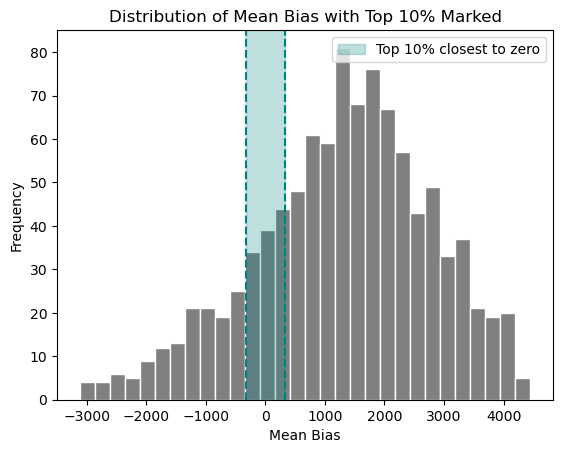

In [73]:
from oggm.utils import rmsd

means = []
stds = []
rmsds = []  

for i in range(len(mass_balance_samples)):
    means.append(mass_balance_samples[i].mean() - mbdf['in_situ_mb'].loc[2000:2019].mean())
    stds.append(mass_balance_samples[i].std() - mbdf['in_situ_mb'].loc[2000:2019].std())
    rmsds.append(rmsd(mass_balance_samples[i], mbdf['in_situ_mb'].loc[2000:2019].values))

# compute the 90th percentile (best of abs mean bias 10%)

abs_means = np.abs(means)
thr = np.percentile(abs_means, 10)   # 10% closest to zero

plt.hist(means, bins=30, color='grey', edgecolor='white')

# Shade the region corresponding to the best 10%
plt.axvspan(-thr, thr, color='teal', alpha=0.25, label='Top 10% closest to zero')

# plot vertical lines for clarity
plt.axvline(-thr, color='teal', linestyle='--')
plt.axvline(+thr, color='teal', linestyle='--')

# labels + title
plt.xlabel("Mean Bias")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Bias with Top 10% Marked")
plt.legend()

plt.show()

When looking into other glaciers, we will likely only have access to the Huggonet data, which will be a singular mass balance value over a period of years. To prepare for this, we will focus on using the mean bias to reduce the parameter ranges.

We can investigate which of these metrics can perform better to constrain the parameters, we will use the metrics of the mass balance between the observed and simulated values: the mean bias.

In [31]:
index = np.where(years[0] == 2003)[0][0]

area_in_rgi_year = []
for area_sample in area_samples:
    area_in_rgi_year.append(area_sample[index])

In [32]:
area_mean_bias = []

for i in range(len(area_in_rgi_year)):
    area_mean_bias.append((area_in_rgi_year[i] - gdir_hef.rgi_area_km2))

area_mean_bias

[5.444665745042078,
 -0.8337703363292333,
 1.7538594441099011,
 1.4813374739085,
 9.760951048064255,
 2.571893414526526,
 2.5693831318998157,
 9.33760513355796,
 4.919061213916002,
 8.367665963549674]

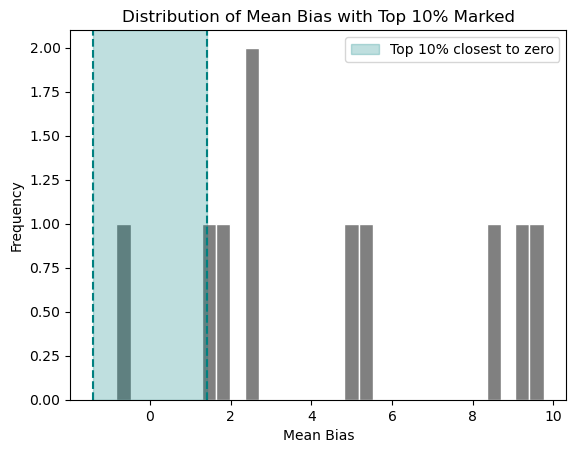

In [33]:
# compute the 90th percentile (best of abs mean bias 10%)

abs_means = np.abs(area_mean_bias)
thr = np.percentile(abs_means, 10)   # 10% closest to zero

plt.hist(area_mean_bias, bins=30, color='grey', edgecolor='white')

# Shade the region corresponding to the best 10%
plt.axvspan(-thr, thr, color='teal', alpha=0.25, label='Top 10% closest to zero')

# plot vertical lines for clarity
plt.axvline(-thr, color='teal', linestyle='--')
plt.axvline(+thr, color='teal', linestyle='--')

# labels + title
plt.xlabel("Mean Bias")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Bias with Top 10% Marked")
plt.legend()

plt.show()

In [36]:
from oggm.core.sensitivity import parameter_bounding

new_lower_bounds, new_upper_bounds, mask, pipe_full, pipe_good = parameter_bounding(X, area_mean_bias, 10)

Selecting top 10%:
  Threshold |bias| <= 1.4166
  Selected 1 out of 10 samples.

=== LINEAR REGRESSION DIAGNOSTICS ===
R² (full parameter space): 0.9650
R² (top 10% region): nan

Regression coefficients in 'good' region:
[0. 0. 0.]
--------------------------------------

Parameter bounds from top performers:
New Lower bounds: [6.35283505 4.68147551 2.06871248]
New Upper bounds: [6.35283505 4.68147551 2.06871248]


/home/chloe/miniconda3/envs/oggm_env/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


From these diagnostics, we can see that our full parameter space is extremely well suited for linear predictability, the top 10% of values less so, but there is still a moderate linear predictability here. This shows that the values still meaningfully map to the bias.

We can also see in the new proposed boundary region, that the melt factor and temperature bias have a strong negative effect on the bias and that the precipitation factor has a strong positive effect on the bias.

From our linear regression method, choosing the best 10% of mean bias (the 10% smallest abs mean bias values), and their corresponding parameters we get the following as the new reduced ranges:

In [ ]:
print("New Lower Bounds: ", new_lower_bounds)
print("New Upper Bounds: ", new_upper_bounds)

New Lower Bounds:  [ 2.12471241  1.01070247 -0.89475558]
New Upper Bounds:  [6.94667449 4.71739563 2.93106086]


In [82]:
geo_df = utils.get_geodetic_mb_dataframe()

geo_df.loc[gdir_hef.rgi_id]['dmdtda'][1] * 1000

/tmp/ipykernel_41479/2018714754.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  geo_df.loc[gdir_hef.rgi_id]['dmdtda'][1] * 1000


-1100.3

In [ ]:
hugonnet_bias = 

means

[-63.76684536112998,
 775.9531884459573,
 -520.1694754815533,
 3392.946724994854,
 2091.055699617172,
 1387.757252215679,
 1645.3515904924777,
 295.3332084555698,
 -1864.9077797467266,
 2032.7000704762536,
 1608.0711500902771,
 1034.5806738544754,
 1339.8401129609424,
 1661.506549944418,
 2002.2289632238096,
 -779.7929986467279,
 3058.4573797819153,
 1382.6873552584855,
 -202.5349731694182,
 1491.8114364237294,
 1990.4501506657148,
 795.5120273075091,
 1662.5710312588894,
 1925.7979740182097,
 2312.973013335525,
 3970.3174713159037,
 799.8239653474216,
 1413.5792086357355,
 433.3187273908786,
 244.29060261361644,
 3226.238445771348,
 2293.498715195073,
 -1222.0054590707355,
 3961.913927453604,
 -498.42379735789063,
 1201.9179408576806,
 2258.7558146251226,
 2909.4268054229988,
 3619.278329421397,
 3244.3501239941693,
 -217.535140713175,
 -1349.3825677872887,
 783.1938383143579,
 2913.9797966702617,
 3878.2691666484343,
 1193.4312617453008,
 720.7184778585638,
 -1958.938703718075,
 -611

These ranges are reduced compared to before. With the main reduction being the lower end of the temperature bias. Let's now generate the new outputs with these reduced parameter ranges and see how the model performs. Here we can validate that our metrics are actually now improved from before.

In [ ]:
# Generate a fresh set of samples with no constraints

X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

# gdir_hef.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this? 
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = new_lower_bounds # Minimum values for each parameter
x_max = new_upper_bounds # Maximum values for each parameter
# The default ranges error with the dynamic spinup, we need to reduce these ranges - ideally to something closer to the Hinteresfirner glacier to be able to complete a dynamic spinup
# Some of these output values are 0 for runoff, 
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 1000 # Number of samples
X_LR = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

YY_LR = runoff_execution(fun_test = run_with_runoff_for_sa, 
                 X = X_LR, #All samples
                 gdir = gdir_hef, # Hinteresfirner Glacier directory
                 years =range(1979, 2020), # years
                 init_model_yr = 1901, # Simulation start year - needs to be early enough to allow for spinup before the period we are interested in
                 ys =1901, # Was 1979
                 min_ys = 1901, # Was 1979
                 ref_area_yr = 2004, # Reference area year - needs to be a year for which we have observed area data for the glacier, so we can use this to constrain the modelled glacier area during the spinup period
                 spinup_period = 21, # Spinup period in years (we are cutting this off, once the glacier has reached an equilibrium state, but this can be changed to a different period if desired)
                 csv_filepath = 'lr_runoff_output.csv',
                 params_csv_filepath = 'lr_params.csv',
                 run_task = tasks.run_from_climate_data,
                 mb_model_method = MultipleFlowlineMassBalance)

2026-03-03 14:51:58: oggm.workflow: Execute entity tasks [run_with_runoff_for_sa] on 1000 glaciers
2026-03-03 14:51:59: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-03 14:51:59: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-03 14:51:59: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-03 14:51:59: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_s

<class 'list'> 1000


Now lets explore the new behaviour of the outputs. We will start by investigating the difference between the mass balance performance metrics since we have some oberved values to compare to. This can validate the success of our parameter bounding here.

Firstly, reading the new metrics from the CSVs for our analysis.

In [ ]:
from oggm.utils import rmsd

lr_mass_balance_samples = []
lr_years = []
lr_runoff_samples = []
lr_area_samples = []
lr_params = []

for i in range(N):
    lr_df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_lr_runoff_output.csv')
    lr_mass_balance_samples.append(lr_df['mass_balance'].values)
    lr_years.append(lr_df['years'].values)
    lr_runoff_samples.append(lr_df['runoff'].values)
    lr_area_samples.append(lr_df['area'].values)

    lr_param_df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_lr_params.csv')
    lr_params.append(lr_param_df)

lr_means = []
lr_stds = []
lr_rmsds = []  

# Calculating our fit-to-data metrics

for i in range(len(lr_mass_balance_samples)):
    lr_means.append(lr_mass_balance_samples[i].mean() - mbdf['in_situ_mb'].loc[2000:2019].mean())
    lr_stds.append(lr_mass_balance_samples[i].std() - mbdf['in_situ_mb'].loc[2000:2019].std())
    lr_rmsds.append(rmsd(lr_mass_balance_samples[i], mbdf['in_situ_mb'].loc[2000:2019].values))

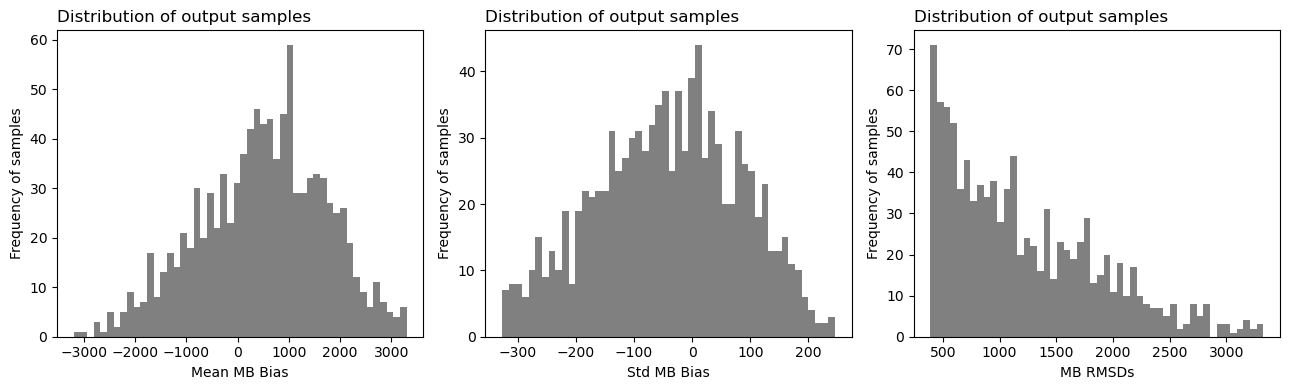

In [ ]:
Y_lab_runoff_dist = ['Mean Runoff', 'Std of Runoff']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(lr_means, bins=50, color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel('Mean MB Bias')

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(lr_stds, bins=50, color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel('Std MB Bias')

plt.subplot(1,3,3), plt.title('Distribution of output samples', loc='left'), plt.hist(lr_rmsds, bins=50, color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel('MB RMSDs')

plt.tight_layout()

We can see above that the mean bias of the mass balance and the standard deviation are still normally distributed, and both of which are now reduced in range than the values we were seeing before constraining the parameters, suggesting that the new parameter range is more realistic than before. We can also see that the RMSD also now has a similar skewed behaviour as before (due to the functions behaviour limiting it to only positive values), the range here is also much smaller than before.

In [ ]:
# compile csvs to plot timeseries and plot to view the mass balance time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
success_index_mean = []

# Colormap and normalization
cmap = plt.cm.coolwarm

# Using the RMSD as a metric to evaluate the success of each simulation, we can colour the lines based on the RMSD value, with a colourbar to show the range of RMSD values. 
# This will allow us to visually identify which simulations are performing better or worse in terms of matching the observed mass balance time series.
for i in range(N):
    lr_df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_lr_runoff_output.csv')
    success_index_mean.append(mean_diff(lr_df['mass_balance'].values, mbdf['in_situ_mb'].loc[df['years'].iloc[0]:df['years'].iloc[-1]].values))

vmin_mean = min(success_index_mean)
vmax_mean = max(success_index_mean)
norm_mean = plt.Normalize(vmin=vmin_mean, vmax=vmax_mean)

<Figure size 1500x500 with 0 Axes>

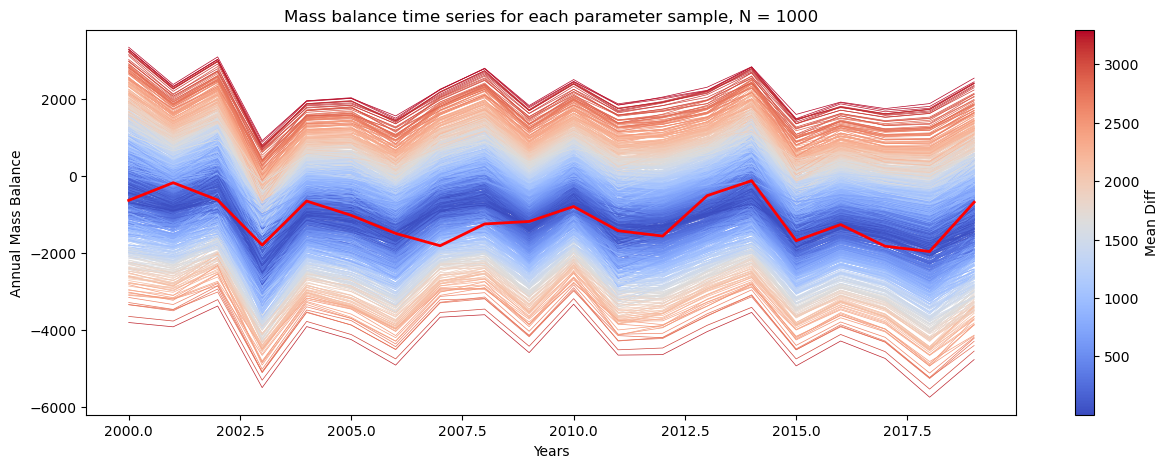

In [ ]:
plt.figure(figsize=(15,5))
fig, ax = plt.subplots(figsize=(15, 5))

for i in range(N):
    lr_df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_lr_runoff_output.csv')
    color = cmap(norm_mean(success_index_mean[i]))
    plt.plot(lr_df['years'], lr_df['mass_balance'], label='sim', color=color, linewidth=0.5)
    plt.title('Mass balance time series for each parameter sample, N = %d' % N)

# Add colorbar linked to the same colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_mean)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Mean Diff')

plt.xlabel('Years')
plt.ylabel('Annual Mass Balance')

plt.plot(range(2000,2020), mbdf['in_situ_mb'].loc[2000:2019], label='obs', color='r', linewidth=2)
plt.show()

We can now see that the plotted Mass balance time series now has mean bias far reduced than before (reduced the range from peaking at 4000 before to 500 now), we can see that there are larger changes within an individual timeseries, likely due to the big dominating shifting effect of the temperature bias has been removed and more focus is now placed on the melt fatcor and precipitation factor which vary more inter-annually.

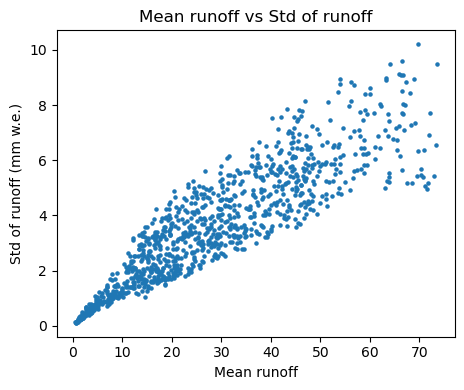

In [ ]:
try: 
    X_LR
except NameError:
    X_LR = np.vstack([p.values for p in lr_params])

try: 
    YY_LR
except NameError:
    YY_LR = hydro_output_metric_calculator(lr_runoff_samples)
    
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY_LR[:,0], YY_LR[:,1], s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),

plt.tight_layout()
plt.show()

Now investigating the runoff output behaviour, we can see that the mean runoff and std of runoff are now both smaller in magnitude, with a slightly tighter positive correlation than before.

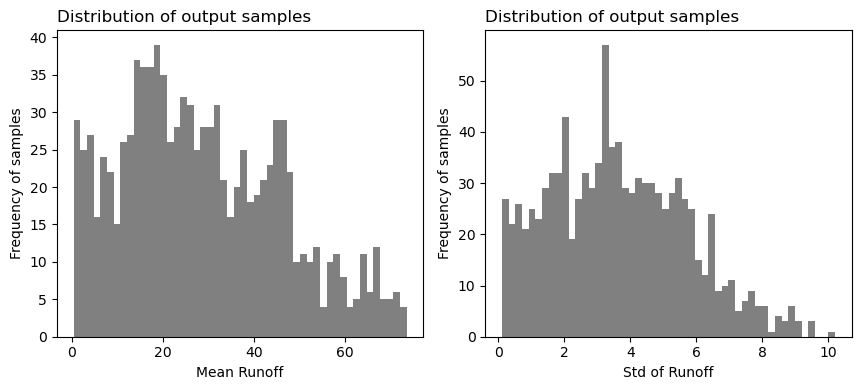

In [ ]:
Y_lab_runoff_dist = ['Mean Runoff', 'Std of Runoff']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_LR[:,0], bins=50, color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel(Y_lab_runoff_dist[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_LR[:,1], bins=50, color='grey');
plt.ylabel('Frequency of samples'), plt.xlabel(Y_lab_runoff_dist[1])

plt.tight_layout()

In [ ]:
# Now let's investigate these simulations by plotting the parameters against the RMSD values, to see if we can identify any relationships between the parameters and the performance of the simulations in terms of matching the observed mass balance time series.
Y_Labels = ['Mean Runoff', 'Std of Runoff']
# Read the parameters for each simulation
params = []

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    params.append(X_LR[i])  # Assuming X is the array of input parameters for each simulation

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])

    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X_LR[:, i], X_LR[:, i-1], 
                         c=YY_LR[:,j], cmap='coolwarm', edgecolors='grey')
        
        plt.ylabel(X_labels[i-1])    
        plt.xlabel(X_labels[i])      

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label(metric +'(Mt)')

    plt.show()

interact(scatter_function, metric=Y_Labels);
  

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

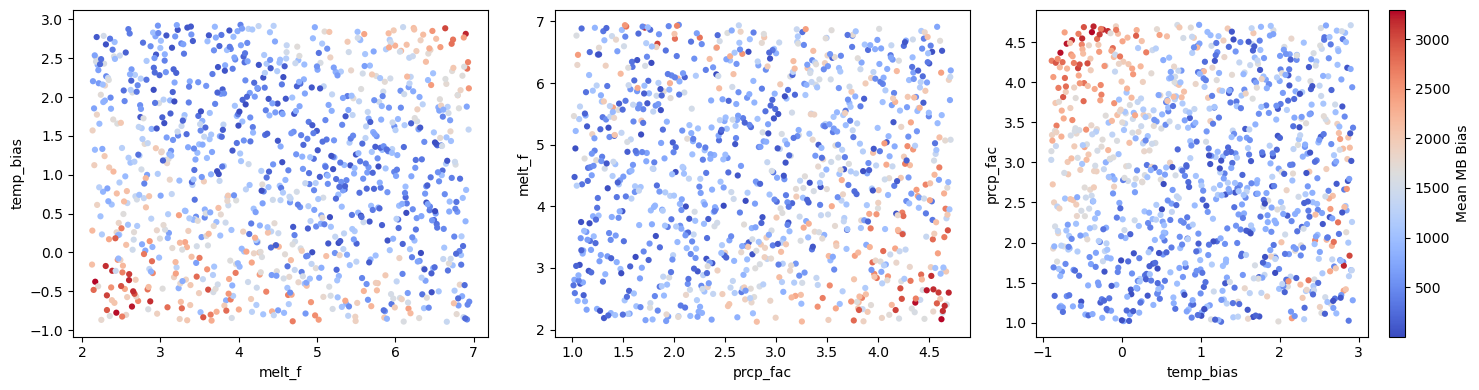

In [ ]:
M = X.shape[1]

import numpy as np
import matplotlib.pyplot as plt

success_index = np.asarray(success_index_mean)
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=success_index.min(), vmax=success_index.max())

j = (i - 1) % X.shape[1]  # previous column (wraps around)
plt.figure(figsize=[15,4])

for i in range(M):
    plt.subplot(1,3,i+1)
    sc = plt.scatter(
        X_LR[:, i], X_LR[:, i-1],
        c=success_index, cmap=cmap, norm=norm, s=20, edgecolors="none"
        )
    if i == 0:   
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])
    if i == 1:
        ymin, ymax = plt.ylim()
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])
    if i == 2:
        plt.xlabel(X_labels[i]); plt.ylabel(X_labels[i-1])

cbar = plt.colorbar(sc)
cbar.set_label("Mean MB Bias")
ax = plt.gca()

plt.tight_layout(); plt.show()


## Qualitative Sensitivity

In [ ]:
Y_Labels = ['Mean Runoff', 'Std of Runoff']

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X_LR[:, i], YY_LR[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

## PAWN Sensitivity

In [ ]:
# Define interactive visualisation function to calculate and visualise sensitivity indices
# for the chosen output metric and different choices of the PAWN tuning parameters (n,Nboot,aggr)

def runoff_pawn_function(metric='Mean Runoff', n = 5, aggr = 'median', Nboot = 500):
    # Extract output metric:
    if metric == 'Mean Runoff':
        i = 0
    elif metric == 'Std of Runoff':
        i = 1   
    Y = YY_LR[:, i]; 

    X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
    
    # Apply PAWN
    # Tuning parameters:
    # n = number of conditioning intervals
    # aggr = statistic to aggregate KS values
    # Nboot = number of bootstrapping resamples used to derive confidence bounds of sensitivity indices   

    # Compute sensitivity indices for Nboot bootstrap resamples
    KS_median, KS_mean, KS_max = PAWN.pawn_indices(X_LR, Y, n, Nboot=Nboot)
    # KS_median and KS_mean and KS_max have shape (Nboot, M)
        
    # Compute mean and confidence intervals of the sensitivity indices across the bootstrap resamples:
    KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median) # shape (M,)
    KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean) # shape (M,)
    KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max) # shape (M,)

    # Plot sensitivity indices:
    plt.figure()
    plt.title("Output Metric for the Runoff = %s" % metric)
    if aggr == 'median':
        pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub, X_Labels=X_labels, Y_Label='sensitivity (median KS)')
    if aggr == 'mean':
        pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub, X_Labels=X_labels, Y_Label='sensitivity (mean KS)')
    if aggr == 'max':
        pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub, X_Labels=X_labels, Y_Label='sensitivity (max KS)')
    plt.show()

interact(runoff_pawn_function, metric = ['Mean Runoff','Std of Runoff'], n = (2, 20, 1), aggr = ['median', 'mean','max'], Nboot = (0, 500, 10));


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

After constraining our boundaries, we can see using PAWN Sensitivity Analysis that the precipitation factor is significantly the most impactful on the runoff when we constrain to appropriate parameter ranges to our sensitivity analysis. However, it also appears to have the biggest uncertainty.